In [1]:
import json
from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from PIL import Image
from tqdm import tqdm

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

import matplotlib.pyplot as plt

In [2]:
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

SPLIT_DIR = BASE_DIR / "data" / "splits"
MODEL_DIR = BASE_DIR / "models"

MODEL_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [3]:
train_df = pd.read_csv(SPLIT_DIR / "train.csv")
val_df = pd.read_csv(SPLIT_DIR / "val.csv")
test_df = pd.read_csv(SPLIT_DIR / "test.csv")

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (24266, 11)
Validation: (5200, 11)
Test: (5201, 11)


In [4]:
target_col = "gender"

print(train_df[target_col].value_counts())

gender
Men       13751
Women      8463
Unisex     1175
Boys        541
Girls       336
Name: count, dtype: int64


In [5]:
classes = sorted(train_df[target_col].unique())

class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(classes)
}

idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}

num_classes = len(classes)

print("Classes:", num_classes)
print(class_to_idx)

with open(MODEL_DIR / "gender_class_to_idx.json", "w") as f:
    json.dump(class_to_idx, f, indent=4)

Classes: 5
{'Boys': 0, 'Girls': 1, 'Men': 2, 'Unisex': 3, 'Women': 4}


In [6]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [7]:
class WardrobeDataset(Dataset):

    def __init__(self, dataframe, class_to_idx, target_col, transform=None):

        self.df = dataframe.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.target_col = target_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):

        row = self.df.iloc[index]

        image_path = row["image_path"]

        label_name = row[self.target_col]

        label = self.class_to_idx[label_name]

        try:
            image = Image.open(image_path).convert("RGB")

        except Exception:
            image = Image.new("RGB", (224,224), color=(255,255,255))

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

In [8]:
BATCH_SIZE = 32

train_dataset = WardrobeDataset(
    train_df,
    class_to_idx,
    target_col,
    transform=train_transform
)

val_dataset = WardrobeDataset(
    val_df,
    class_to_idx,
    target_col,
    transform=eval_transform
)

test_dataset = WardrobeDataset(
    test_df,
    class_to_idx,
    target_col,
    transform=eval_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Train batches:", len(train_loader))

Train batches: 759


In [9]:
model = models.mobilenet_v2(
    weights=models.MobileNet_V2_Weights.DEFAULT
)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    num_classes
)

model = model.to(device)

print("Gender model ready.")

Gender model ready.


In [10]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [12]:
def evaluate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in tqdm(loader):

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [16]:
EPOCHS = 5

best_val_acc = 0.0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_model_path = MODEL_DIR / "mobilenetv2_gender_best.pth"

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-"*40)

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")

    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(model.state_dict(), best_model_path)

        print("Best gender model saved.")

print("\nTraining completed.")

print("Best validation accuracy:", best_val_acc)


Epoch 1/5
----------------------------------------


100%|████████████████████████████████████████| 163/163 [00:20<00:00,  7.96it/s]


Train Loss: 0.1409 | Train Acc: 0.9495
Val Loss: 0.2345 | Val Acc: 0.9248
Best gender model saved.

Epoch 2/5
----------------------------------------


100%|████████████████████████████████████████| 163/163 [01:02<00:00,  2.61it/s]


Train Loss: 0.1212 | Train Acc: 0.9578
Val Loss: 0.2416 | Val Acc: 0.9250
Best gender model saved.

Epoch 3/5
----------------------------------------


...

Train Loss: 0.1030 | Train Acc: 0.9634
Val Loss: 0.2329 | Val Acc: 0.9312
Best gender model saved.

Epoch 4/5
----------------------------------------


100%|████████████████████████████████████████| 163/163 [00:19<00:00,  8.29it/s]


Train Loss: 0.0926 | Train Acc: 0.9661
Val Loss: 0.2546 | Val Acc: 0.9275

Epoch 5/5
----------------------------------------


100%|████████████████████████████████████████| 163/163 [00:22<00:00,  7.41it/s]

Train Loss: 0.0810 | Train Acc: 0.9709
Val Loss: 0.2537 | Val Acc: 0.9275

Training completed.
Best validation accuracy: 0.9311538461538461


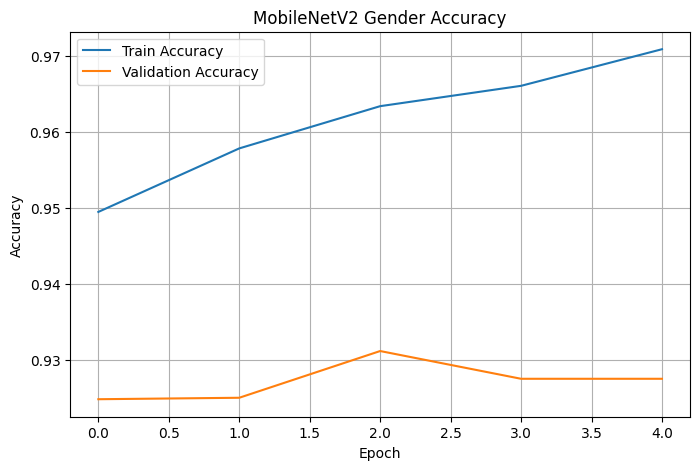

In [17]:
plt.figure(figsize=(8,5))

plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")

plt.title("MobileNetV2 Gender Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

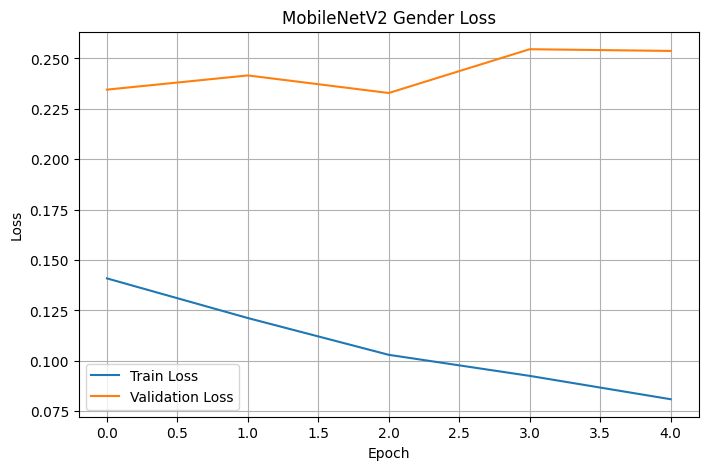

In [18]:
plt.figure(figsize=(8,5))

plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")

plt.title("MobileNetV2 Gender Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()